In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!cp '/content/drive/MyDrive/GNR638_assignment/train_data.zip' '/content/'


In [ ]:
!unzip -q '/content/train_data.zip'


In [ ]:
!pip -q install timm torchmetrics scikit-learn albumentations fvcore seaborn ptflops

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 29.8 MB/s eta 0:00:00


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import os
import random
import shutil
import torch
import torch.nn as nn
import torch.optim as optim
import timm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from fvcore.nn import FlopCountAnalysis, parameter_count_table
from torch.utils.data import Subset
import cv2
from ptflops import get_model_complexity_info
from sklearn.preprocessing import StandardScaler

In [ ]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
set_seed(42)
NUM_CLASSES = 30

In [ ]:
model_name = "resnet50"

In [ ]:
train_dir = "/content/AID_split/train"
val_dir = "/content/AID_split/val"
test_dir = "/content/AID_split/test"
base = "/content/AID_split"

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Data Preparation



##Splitting Dataset

In [ ]:
source_dir = "/content/train_data"
output_dir = base

train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

for split in ['train','val','test']:
    os.makedirs(os.path.join(output_dir, split), exist_ok=True)
classes = os.listdir(source_dir)

for cls in classes:

    class_path = os.path.join(source_dir, cls)

    if not os.path.isdir(class_path):
        continue

    images = os.listdir(class_path)

    random.shuffle(images)

    total = len(images)

    train_end = int(train_ratio * total)
    val_end = int((train_ratio + val_ratio) * total)

    train_images = images[:train_end]
    val_images = images[train_end:val_end]
    test_images = images[val_end:]


    for split_name, split_images in zip(
        ['train','val','test'],
        [train_images, val_images, test_images]
    ):

        split_class_dir = os.path.join(output_dir, split_name, cls)
        os.makedirs(split_class_dir, exist_ok=True)

        for img in split_images:

            src = os.path.join(class_path, img)
            dst = os.path.join(split_class_dir, img)

            shutil.copy(src, dst)

print("Dataset successfully split!")


Dataset successfully split!


## Counting data

In [ ]:
def count_images(folder):

    total = 0

    for root, dirs, files in os.walk(folder):
        total += len(files)

    return total


train_count = count_images(os.path.join(output_dir,"train"))
val_count = count_images(os.path.join(output_dir,"val"))
test_count = count_images(os.path.join(output_dir,"test"))

print("Train images:", train_count)
print("Validation images:", val_count)
print("Test images:", test_count)


Train images: 4882
Validation images: 1047
Test images: 1064


## Tranformation

In [ ]:
train_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(10),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

val_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])


## Loading data

In [ ]:
train_dataset = datasets.ImageFolder(
    train_dir,
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    val_dir,
    transform=val_transform
)

test_dataset = datasets.ImageFolder(
    test_dir,
    transform=val_transform
)

print("Number of classes:", len(train_dataset.classes))


Number of classes: 30


In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)


# Common functions


In [ ]:
 def initialize_model(model_name):
    model = timm.create_model(model_name, pretrained=True, num_classes=NUM_CLASSES)
    model = model.to(device)
    return model

In [ ]:
def freeze_all_but_last(model):
  for param in model.parameters():
    param.requires_grad = False

  for param in model.fc.parameters():
      param.requires_grad = True

  return model

In [ ]:
criterion = nn.CrossEntropyLoss()


In [ ]:
def evaluate(model, loader):

    model.eval()

    total = 0
    correct = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, preds = torch.max(outputs,1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

    return correct / total


# Experiment 1

In [ ]:
def report_efficiency(model):
    """Reports parameters, MACs, and FLOPs."""
    macs, params = get_model_complexity_info(model, (3, 224, 224), as_strings=True, print_per_layer_stat=False)
    print(f"Parameters: {params}, MACs: {macs}")

In [ ]:
def train_epoch_exp1(model, loader):


    print("Training ...")
    model.train()

    total = 0
    correct = 0
    running_loss = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, preds = torch.max(outputs,1)

        total += labels.size(0)
        correct += (preds == labels).sum().item()

    acc = correct / total

    return running_loss / len(loader), acc


In [ ]:
model = initialize_model(model_name)

optimizer = optim.Adam(
    model.fc.parameters(),
    lr=0.001
)

report_efficiency(model)
model = freeze_all_but_last(model)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Parameters: 23.57 M, MACs: 4.13 GMac


In [ ]:
print(f"\n{'='*50}\nStarting Experiment 1: Linear Probe for {model_name}\n{'='*50}")

epochs = 30

train_acc_list = []
val_acc_list = []

for epoch in range(epochs):

    loss, train_acc = train_epoch_exp1(model, train_loader)

    val_acc = evaluate(model, val_loader)

    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )



Starting Experiment 1: Linear Probe for resnet50
Training ...
Epoch 1/30 | Train Acc: 0.4138 | Val Acc: 0.6285
Training ...
Epoch 2/30 | Train Acc: 0.6790 | Val Acc: 0.7173
Training ...
Epoch 3/30 | Train Acc: 0.7478 | Val Acc: 0.7354
Training ...
Epoch 4/30 | Train Acc: 0.7728 | Val Acc: 0.7584
Training ...
Epoch 5/30 | Train Acc: 0.7935 | Val Acc: 0.7708
Training ...
Epoch 6/30 | Train Acc: 0.8083 | Val Acc: 0.7861
Training ...
Epoch 7/30 | Train Acc: 0.8306 | Val Acc: 0.7927
Training ...
Epoch 8/30 | Train Acc: 0.8357 | Val Acc: 0.7985
Training ...
Epoch 9/30 | Train Acc: 0.8347 | Val Acc: 0.8128
Training ...
Epoch 10/30 | Train Acc: 0.8507 | Val Acc: 0.8090
Training ...
Epoch 11/30 | Train Acc: 0.8492 | Val Acc: 0.8166
Training ...
Epoch 12/30 | Train Acc: 0.8603 | Val Acc: 0.8290
Training ...
Epoch 13/30 | Train Acc: 0.8667 | Val Acc: 0.8319
Training ...
Epoch 14/30 | Train Acc: 0.8718 | Val Acc: 0.8290
Training ...
Epoch 15/30 | Train Acc: 0.8777 | Val Acc: 0.8348
Training ...
E

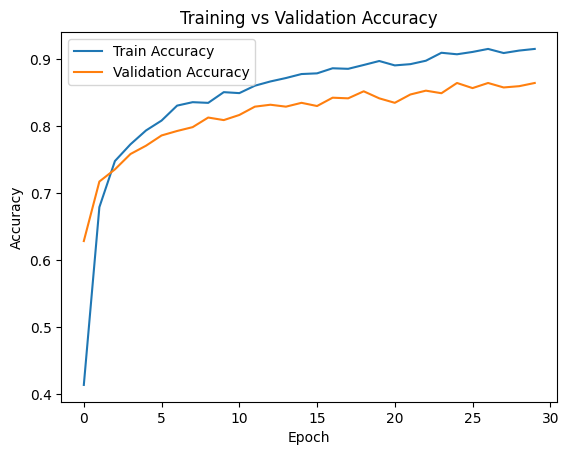

In [ ]:
plt.plot(train_acc_list,label="Train Accuracy")
plt.plot(val_acc_list,label="Validation Accuracy")

plt.legend()
plt.title("Training vs Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.show()


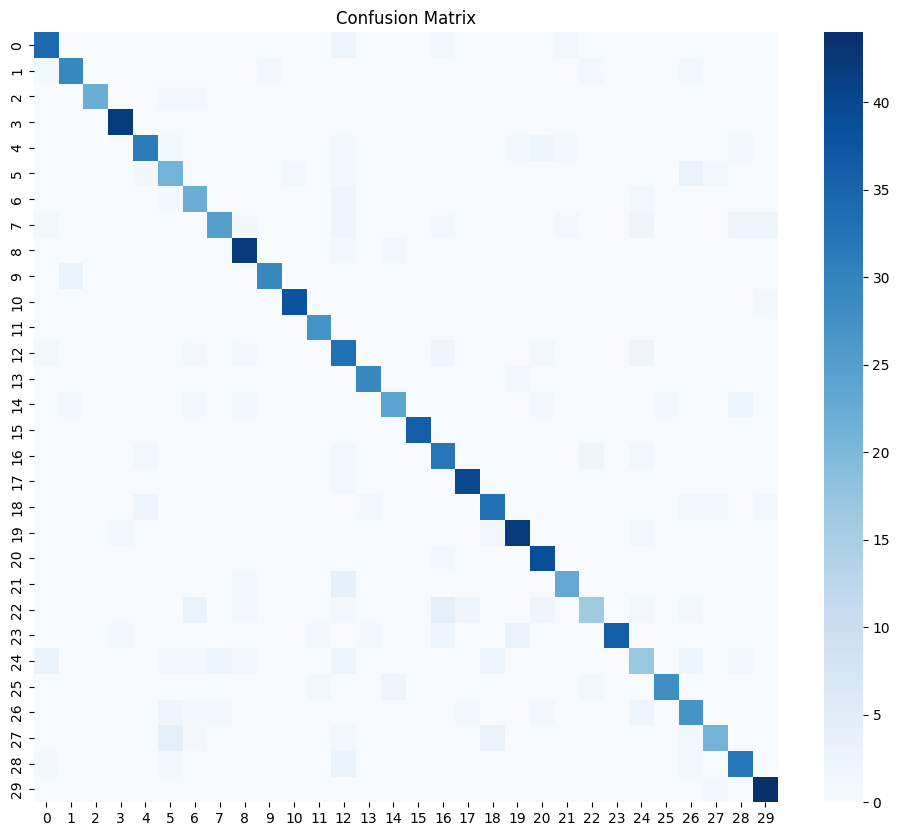

In [ ]:
all_preds = []
all_labels = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs,1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12,10))
sns.heatmap(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.show()


##PCA

In [ ]:
features = []
labels_list = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        x = model.forward_features(images)

        x = torch.mean(x,(2,3))

        features.append(x.cpu().numpy())
        labels_list.append(labels.numpy())

features = np.concatenate(features)
labels_list = np.concatenate(labels_list)


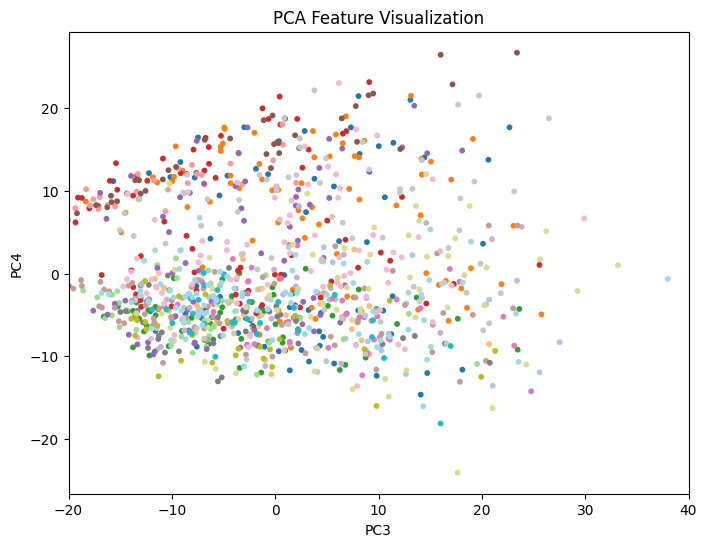

In [ ]:
pca = PCA(n_components=2)
from sklearn.preprocessing import StandardScaler
features_scaled = StandardScaler().fit_transform(features)

reduced = pca.fit_transform(features_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    reduced[:,0],
    reduced[:,1],
    c=labels_list,
    cmap="tab20",
    s=10
)
plt.xlim(-20, 40)
# plt.ylim(-2, 2)
plt.title("PCA Feature Visualization")

plt.xlabel("PC3")
plt.ylabel("PC4")

plt.show()


# Experiment 2

In [ ]:
def count_trainable_params(model):

    total = sum(p.numel() for p in model.parameters())

    trainable = sum(
        p.numel() for p in model.parameters() if p.requires_grad
    )

    percent = (trainable / total) * 100

    return trainable, percent


In [ ]:
def get_grad_norm(model):

    total_norm = 0
    for p in model.parameters():
        if p.grad is not None:

            param_norm = p.grad.data.norm(2)
            total_norm += param_norm.item() ** 2

    return total_norm ** 0.5


#Strategy 1: Linear Probe: Same as earlier

#Strategy 2: Last Block Fine-Tuning

In [ ]:
def last_block_ft(model):

    for param in model.parameters():
        param.requires_grad = False

    for param in model.layer4.parameters():
        param.requires_grad = True

    for param in model.fc.parameters():
        param.requires_grad = True

    return model


#Strategy 3: Full Fine-Tuning

In [ ]:
def full_finetune(model):

    for param in model.parameters():
        param.requires_grad = True

    return model


#Strategy 4: Selective 20% Unfreezing

In [ ]:
def selective_unfreeze(model, percent=0.2):
    # Freeze all first
    for p in model.parameters():
        p.requires_grad = False

    # Unfreeze classifier
    for p in model.fc.parameters():
        p.requires_grad = True

    # Filter backbone parameters
    backbone_params = []
    for name, p in model.named_parameters():
        if 'fc' not in name:
            backbone_params.append(p)

    total_backbone_params = sum(p.numel() for p in backbone_params)
    target_unfreeze = total_backbone_params * percent

    # Unfreeze from deep to early until 20% limit reached
    current_unfrozen = 0
    for p in reversed(backbone_params):
        if current_unfrozen < target_unfreeze:
            p.requires_grad = True
            current_unfrozen += p.numel()

    print(f"Unfrozen {current_unfrozen} / {total_backbone_params} backbone parameters ({current_unfrozen/total_backbone_params:.1%})")
    return model


In [ ]:
def train_model_exp2(model, epochs=30):
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=0.0001
    )

    train_acc_list = []
    val_acc_list = []
    # Change to a dictionary to track individual layers
    layer_grad_history = {name: [] for name, p in model.named_parameters() if p.requires_grad}
    train_loss_list = []

    for epoch in range(epochs):
        model.train()
        correct, total, running_loss = 0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()

            for name, param in model.named_parameters():
                if param.grad is not None:
                    # Capture the L2 norm for this specific layer/parameter
                    norm = param.grad.norm(2).item()
                    layer_grad_history[name].append(norm)

            optimizer.step()

            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()
            running_loss += loss.item()

        train_acc = correct / total
        avg_train_loss = running_loss / len(train_loader)
        val_acc = evaluate(model, val_loader)

        train_acc_list.append(train_acc)
        val_acc_list.append(val_acc)
        train_loss_list.append(avg_train_loss)

        print(
            f"Epoch {epoch+1} | Train Acc: {train_acc:.3f} | Train Loss: {avg_train_loss:.3f} | Val Acc: {val_acc:.3f}"
        )

    return train_acc_list, val_acc_list, layer_grad_history, train_loss_list

In [ ]:
print(f"\n{'='*50}\nStarting Experiment 2: Finetuning for {model_name}\n{'='*50}")

strategies = {
    "LinearProbe": freeze_all_but_last,
    "LastBlockFT": last_block_ft,
    "FullFT": full_finetune,
    "Selective20": selective_unfreeze
}

results = {}

for name, strategy in strategies.items():

    print("\nRunning:", name)

    model = initialize_model(model_name)
    model = strategy(model)

    trainable, percent = count_trainable_params(model)

    print("Trainable Params:", trainable)
    print("Percent:", percent)

    train_acc, val_acc, grads, train_loss = train_model_exp2(model, epochs=10)

    results[name] = {
        "train": train_acc,
        "val": val_acc,
        "grad": grads,
        "percent": percent,
        "train_loss": train_loss
    }


Starting Experiment 2: Finetuning for resnet50

Running: LinearProbe


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Trainable Params: 61470
Percent: 0.2608031344913439
Epoch 1 | Train Acc: 0.117 | Train Loss: 3.308 | Val Acc: 0.293
Epoch 2 | Train Acc: 0.355 | Train Loss: 3.135 | Val Acc: 0.465
Epoch 3 | Train Acc: 0.483 | Train Loss: 2.983 | Val Acc: 0.532
Epoch 4 | Train Acc: 0.536 | Train Loss: 2.846 | Val Acc: 0.564
Epoch 5 | Train Acc: 0.574 | Train Loss: 2.713 | Val Acc: 0.600
Epoch 6 | Train Acc: 0.606 | Train Loss: 2.595 | Val Acc: 0.625
Epoch 7 | Train Acc: 0.644 | Train Loss: 2.479 | Val Acc: 0.631
Epoch 8 | Train Acc: 0.653 | Train Loss: 2.380 | Val Acc: 0.651
Epoch 9 | Train Acc: 0.667 | Train Loss: 2.286 | Val Acc: 0.664
Epoch 10 | Train Acc: 0.686 | Train Loss: 2.198 | Val Acc: 0.676

Running: LastBlockFT


Trainable Params: 15026206
Percent: 63.75275133093605
Epoch 1 | Train Acc: 0.192 | Train Loss: 3.226 | Val Acc: 0.391
Epoch 2 | Train Acc: 0.495 | Train Loss: 2.471 | Val Acc: 0.605
Epoch 3 | Train Acc: 0.703 | Train Loss: 1.529 | Val Acc: 0.770
Epoch 4 | Train Acc: 0.790 | Train Loss: 0.973 | Val Acc: 0.818
Epoch 5 | Train Acc: 0.834 | Train Loss: 0.684 | Val Acc: 0.860
Epoch 6 | Train Acc: 0.868 | Train Loss: 0.521 | Val Acc: 0.878
Epoch 7 | Train Acc: 0.881 | Train Loss: 0.427 | Val Acc: 0.890
Epoch 8 | Train Acc: 0.897 | Train Loss: 0.362 | Val Acc: 0.908
Epoch 9 | Train Acc: 0.916 | Train Loss: 0.307 | Val Acc: 0.911
Epoch 10 | Train Acc: 0.930 | Train Loss: 0.261 | Val Acc: 0.919

Running: FullFT
Trainable Params: 23569502
Percent: 100.0
Epoch 1 | Train Acc: 0.207 | Train Loss: 3.191 | Val Acc: 0.467
Epoch 2 | Train Acc: 0.592 | Train Loss: 2.084 | Val Acc: 0.773
Epoch 3 | Train Acc: 0.800 | Train Loss: 0.950 | Val Acc: 0.868
Epoch 4 | Train Acc: 0.865 | Train Loss: 0.533 | Val A

## Accuracy vs Unfrozen Parameters

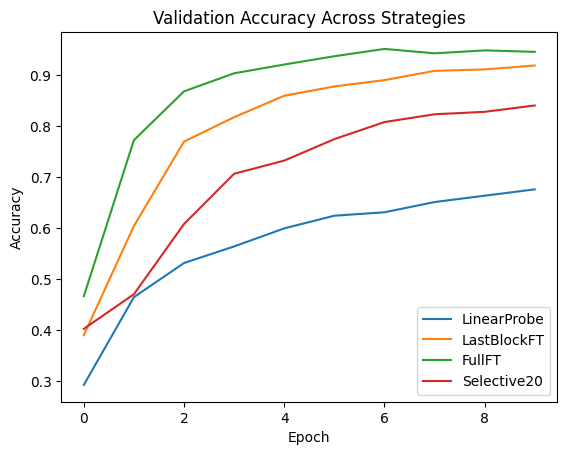

In [ ]:
for name,data in results.items():
    plt.plot(data["val"], label=name)

plt.legend()
plt.title("Validation Accuracy Across Strategies")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()


##  Convergence Stability

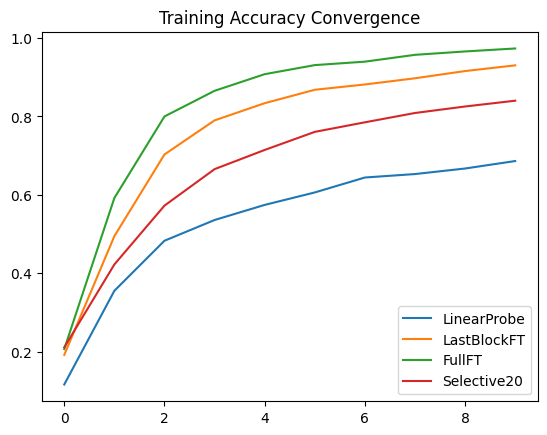

In [ ]:
for name,data in results.items():
    plt.plot(data["train"], label=name)

plt.legend()
plt.title("Training Accuracy Convergence")
plt.show()


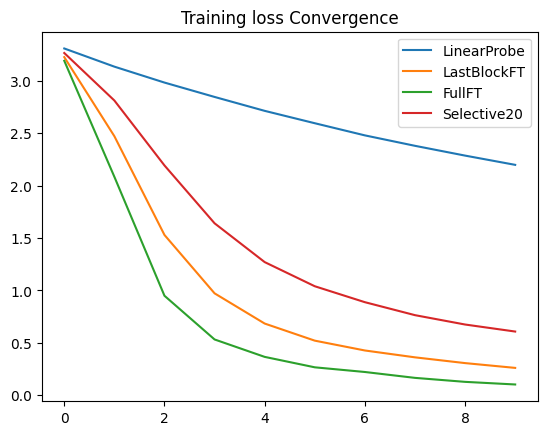

In [ ]:
for name,data in results.items():
    plt.plot(data["train_loss"], label=name)

plt.legend()
plt.title("Training loss Convergence")
plt.show()

#Gradient Norm Comparison

In [ ]:
def plot_gradient_flow(layer_grad_history):
    names = []
    avg_norms = []

    for name, norms in layer_grad_history.items():
        if "weight" in name: # Only plot weights to keep it clean
            if 'conv' in name:
                names.append(name.split('.')[:3]+'.'+name.split('.')[2])
            elif 'fc' in name:
                names.append(name.split('.')[0])

        avg_norms.append(sum(norms) / len(norms))

    plt.figure(figsize=(12, 6))
    plt.bar(range(len(avg_norms)), avg_norms)
    plt.xticks(range(len(names)), names, rotation=90)
    plt.ylabel("Average Gradient Norm")
    plt.title("Gradient Flow Across Layers")
    plt.tight_layout()
    plt.show()

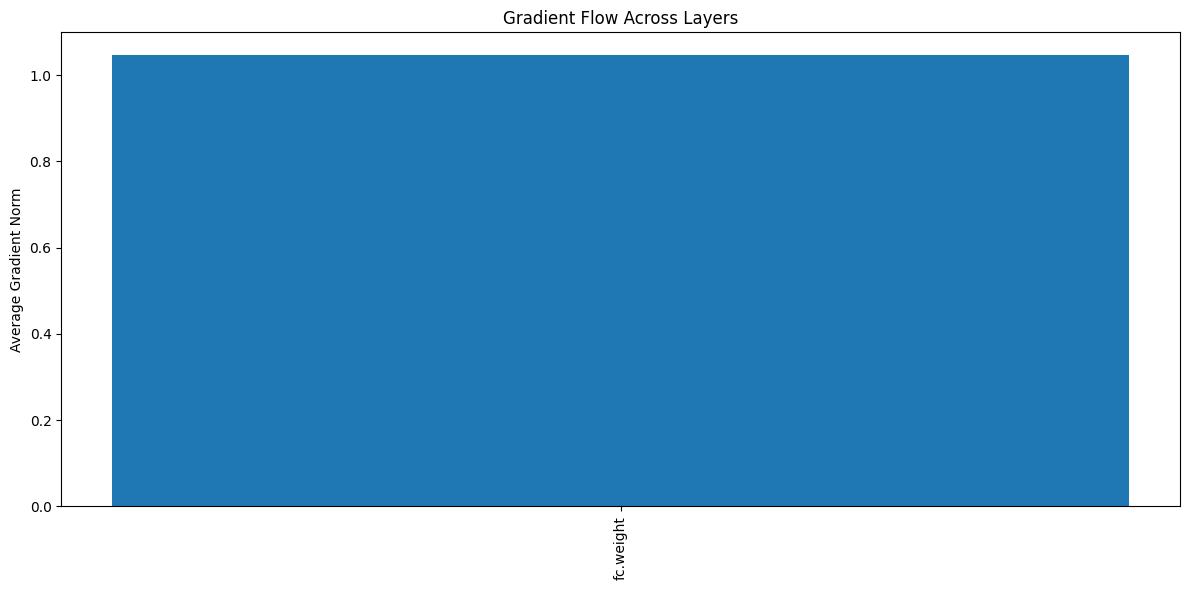

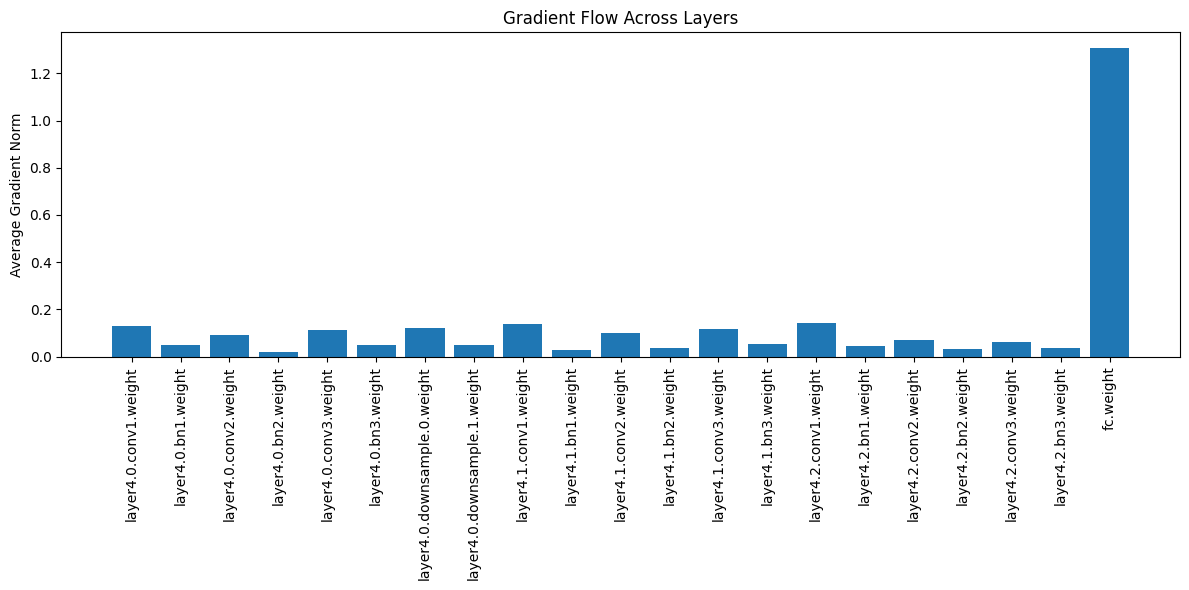

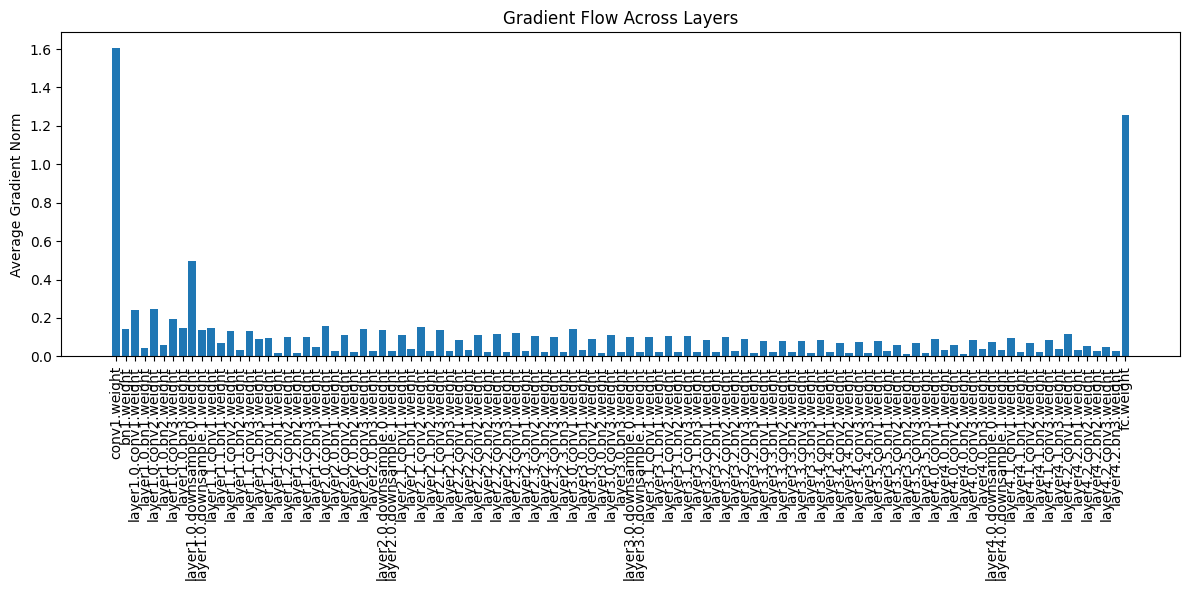

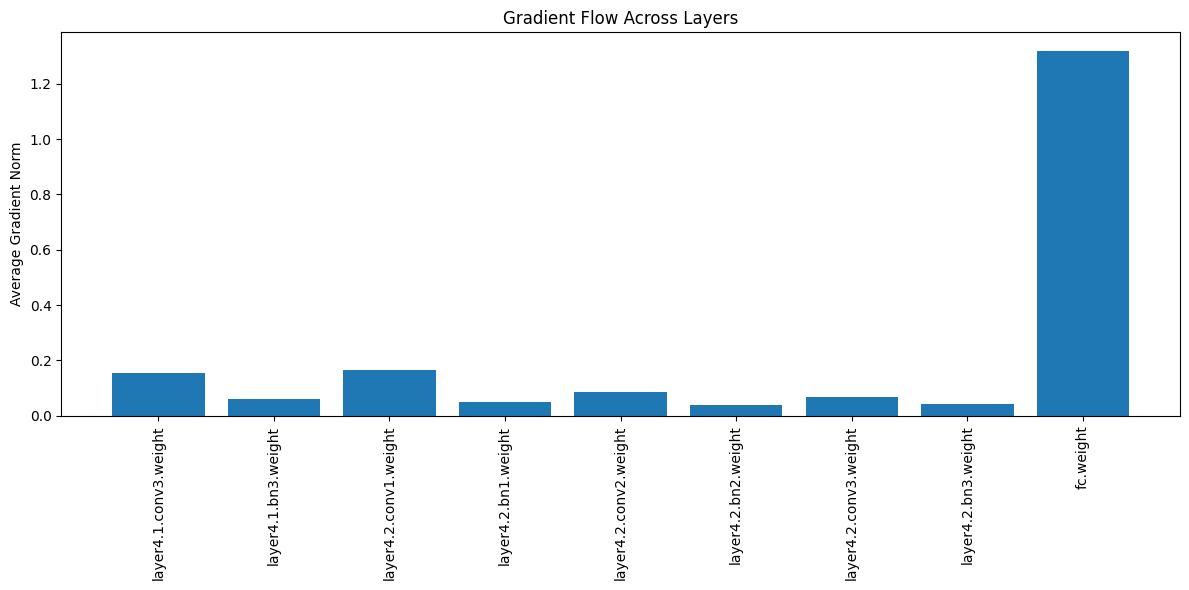

In [ ]:
for name,data in results.items():
      plot_gradient_flow(data['grad'])
# for name,data in results.items():

#     plt.plot(data["grad"], label=name)

# plt.legend()
# plt.title("Gradient Norm Comparison")
# plt.show()


#Experiment 3 fewshot learning

In [ ]:

def create_subset(dataset, percentage, seed=42):

    np.random.seed(seed)
    total_size = len(dataset)
    subset_size = int(total_size * percentage)
    indices = np.random.choice(total_size, subset_size, replace=False)
    subset = Subset(dataset, indices)

    return subset


In [ ]:
train_100 = train_dataset
train_20 = create_subset(train_dataset, 0.20)
train_5 = create_subset(train_dataset, 0.05)

print("Full dataset:", len(train_100))
print("20% dataset:", len(train_20))
print("5% dataset:", len(train_5))


Full dataset: 4882
20% dataset: 976
5% dataset: 244


In [ ]:
loader_100 = DataLoader(train_100, batch_size=32, shuffle=True)
loader_20 = DataLoader(train_20, batch_size=32, shuffle=True)
loader_5 = DataLoader(train_5, batch_size=32, shuffle=True)


In [ ]:
def run_fewshot(train_loader, epochs = 10):

    model = initialize_model(model_name="resnet50")
    model = freeze_all_but_last(model)

    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=0.001
    )

    train_acc_list = []

    for epoch in range(epochs):
        model.train()
        correct = 0
        total = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, preds = torch.max(outputs,1)
            total += labels.size(0)
            correct += (preds==labels).sum().item()
        train_acc_list.append(correct/total)

    val_acc = evaluate(model, val_loader)

    return train_acc_list[-1], val_acc

In [ ]:
print(f"\n{'='*50}\nStarting Experiment 3: Few-shot for {model_name}\n{'='*50}")

few_shot_epoch = 20
train_acc_100, acc_100 = run_fewshot(loader_100, few_shot_epoch)
train_acc_20, acc_20 = run_fewshot(loader_20, few_shot_epoch)
train_acc_5, acc_5 = run_fewshot(loader_5, few_shot_epoch)

print("Accuracy 100%:", acc_100, f"(Train: {train_acc_100:.3f}, Val: {acc_100:.3f}, Gap: {(train_acc_100 - acc_100):.3f})")
print("Accuracy 20%:", acc_20, f"(Train: {train_acc_20:.3f}, Val: {acc_20:.3f}, Gap: {(train_acc_20 - acc_20):.3f})")
print("Accuracy 5%:", acc_5, f"(Train: {train_acc_5:.3f}, Val: {acc_5:.3f}, Gap: {(train_acc_5 - acc_5):.3f})")
# Tabular Summary of results
import pandas as pd
df_results = pd.DataFrame({
    'Scenario': ['100% Data', '20% Data', '5% Data'],
    'Train Accuracy': [train_acc_100, train_acc_20, train_acc_5],
    'Validation Accuracy': [acc_100, acc_20, acc_5]
})
df_results['Train-Val Gap'] = df_results['Train Accuracy'] - df_results['Validation Accuracy']
df_results['Relative Drop (%)'] = (acc_100 - df_results['Validation Accuracy']) / acc_100 * 100
print("Few-Shot Results Table:")
print(df_results.to_markdown())


Starting Experiment 3: Few-shot for resnet50
Accuracy 100%: 0.8500477554918816 (Train: 0.895, Val: 0.850, Gap: 0.045)
Accuracy 20%: 0.725883476599809 (Train: 0.869, Val: 0.726, Gap: 0.143)
Accuracy 5%: 0.5023877745940784 (Train: 0.885, Val: 0.502, Gap: 0.383)
Few-Shot Results Table:
|    | Scenario   |   Train Accuracy |   Validation Accuracy |   Train-Val Gap |   Relative Drop (%) |
|---:|:-----------|-----------------:|----------------------:|----------------:|--------------------:|
|  0 | 100% Data  |         0.895125 |              0.850048 |       0.0450772 |              0      |
|  1 | 20% Data   |         0.868852 |              0.725883 |       0.142969  |             14.6067 |
|  2 | 5% Data    |         0.885246 |              0.502388 |       0.382858  |             40.8989 |


In [ ]:
delta = (acc_100 - acc_5) / acc_100
print("Relative Performance Drop:", delta)


Relative Performance Drop: 0.40898876404494383


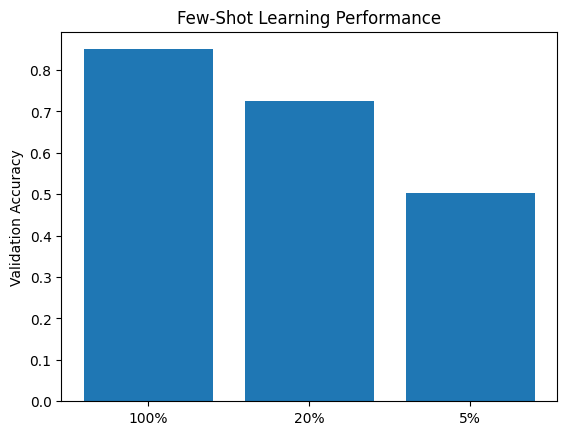

In [ ]:
labels = ["100%","20%","5%"]

accs = [acc_100, acc_20, acc_5]

plt.bar(labels, accs)
plt.title("Few-Shot Learning Performance")
plt.ylabel("Validation Accuracy")
plt.show()


# Experiment 4




In [ ]:
def add_gaussian_noise(images, sigma):
    noise = torch.randn_like(images) * sigma

    return images + noise


In [ ]:

def motion_blur(image):
    kernel = np.zeros((9,9))
    kernel[4,:] = np.ones(9)/9

    return cv2.filter2D(image, -1, kernel)


In [ ]:
def brightness_shift(images, factor):

    return torch.clamp(images * factor, 0, 1)


In [ ]:
def evaluate_with_corruption(loader, corruption, param):
    model.eval()

    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)

        if corruption == "gaussian":
            images = add_gaussian_noise(images, param)
        elif corruption == "brightness":
            images = brightness_shift(images, param)

        outputs = model(images)
        _, preds = torch.max(outputs,1)

        total += labels.size(0)
        correct += (preds.cpu()==labels).sum().item()

    return correct/total


In [ ]:
acc_noise_005 = evaluate_with_corruption(test_loader,"gaussian",0.05)
acc_noise_01 = evaluate_with_corruption(test_loader,"gaussian",0.1)
acc_noise_02 = evaluate_with_corruption(test_loader,"gaussian",0.2)


In [ ]:
print(f"Gaussian 0.2 Accuracy: {acc_noise_02:.3f}")
error_noise = 1 - acc_noise_02
print("Corruption Error:", error_noise)
clean_acc = evaluate(model,test_loader)
robustness = acc_noise_02 / clean_acc

print("Relative Robustness:", robustness)

print(f"Gaussian 0.1 Accuracy: {acc_noise_01:.3f}")
error_noise = 1 - acc_noise_01
print("Corruption Error:", error_noise)
clean_acc = evaluate(model,test_loader)
robustness = acc_noise_01 / clean_acc
print("Relative Robustness:", robustness)

print(f"Gaussian 0.05 Accuracy: {acc_noise_005:.3f}")
error_noise = 1 - acc_noise_005
print("Corruption Error:", error_noise)
clean_acc = evaluate(model,test_loader)
robustness = acc_noise_005 / clean_acc
print("Relative Robustness:", robustness)

acc_bright = evaluate_with_corruption(test_loader,"brightness",1.3)
print(f"Bright Accuracy: {acc_bright:.3f}")
error_noise = 1 - acc_bright
print("Corruption Error:", error_noise)
clean_acc = evaluate(model,test_loader)
robustness = acc_bright / clean_acc
print("Relative Robustness:", robustness)

acc_blur = evaluate_with_corruption(test_loader, "motion_blur", None)
print(f"Motion Blur Accuracy: {acc_blur:.3f}")
error_noise = 1 - acc_blur
print("Corruption Error:", error_noise)
clean_acc = evaluate(model,test_loader)
robustness = acc_blur / clean_acc
print("Relative Robustness:", robustness)


Gaussian 0.2 Accuracy: 0.444
Corruption Error: 0.5563909774436091
Relative Robustness: 0.5291479820627802
Gaussian 0.1 Accuracy: 0.690
Corruption Error: 0.3101503759398496
Relative Robustness: 0.8228699551569506
Gaussian 0.05 Accuracy: 0.765
Corruption Error: 0.2349624060150376
Relative Robustness: 0.9125560538116592
Bright Accuracy: 0.183
Corruption Error: 0.8167293233082706
Relative Robustness: 0.218609865470852
Motion Blur Accuracy: 0.838
Corruption Error: 0.16165413533834583
Relative Robustness: 1.0


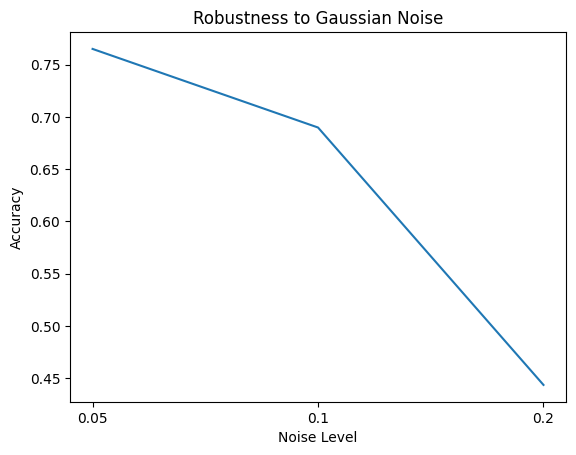

In [ ]:
levels = ["0.05","0.1","0.2"]

accs = [acc_noise_005, acc_noise_01, acc_noise_02]

plt.plot(levels, accs)
plt.title("Robustness to Gaussian Noise")
plt.xlabel("Noise Level")
plt.ylabel("Accuracy")
plt.show()


# Experiment 5

In [ ]:
model = initialize_model(model_name)
model = freeze_all_but_last(model)
model.eval()


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act1): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act1): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (drop_block): Identity()
      (act2): ReLU(inplace=True)
      (aa): Identity()
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     

In [ ]:
probe_layers = ['layer1', 'layer3', 'layer4']


In [ ]:
samples_per_class = 30
indices = []
class_counts = {i:0 for i in range(30)}

for idx,(img,label) in enumerate(train_dataset):
    if class_counts[label] < samples_per_class:
        indices.append(idx)
        class_counts[label]+=1

    if sum(class_counts.values()) == 900:
        break


probe_subset = torch.utils.data.Subset(train_dataset, indices)
probe_loader = DataLoader(probe_subset, batch_size=32)


In [ ]:
def extract_features(layer_name):

    features = []
    labels = []
    # Ensure model is in evaluation mode
    model.eval()

    # Register a hook to capture the output of the desired layer
    activations = {}
    def get_activation(name):
        def hook(model, input, output):
            activations[name] = output.detach()
        return hook

    # Choose the layer to hook based on layer_name for ResNet
    hook_handle = None
    if layer_name == 'layer1':
        hook_handle = model.layer1.register_forward_hook(get_activation('target_layer'))
    elif layer_name == 'layer3':
        hook_handle = model.layer3.register_forward_hook(get_activation('target_layer'))
    elif layer_name == 'layer4':
        hook_handle = model.layer4.register_forward_hook(get_activation('target_layer'))
    else:
        raise ValueError(f"Unknown layer name: {layer_name} for ResNet")

    with torch.no_grad():
        for images, targets in probe_loader:
            images = images.to(device)
            # Pass images through the model; the hook will capture the intermediate output
            _ = model(images) # We don't need the final output, just the intermediate activation

            # Get the captured activation
            output_features = activations['target_layer']
            # Global average pooling (if it's a feature map) before flattening
            if output_features.dim() == 4: # If it's a feature map [B, C, H, W]
                output_features = torch.mean(output_features, (2, 3)) # Global average pooling to [B, C]

            features.append(output_features.cpu().numpy())
            labels.append(targets.numpy())

    # Remove the hook after use to prevent memory leaks and unintended behavior
    if hook_handle: # Check if hook was registered
        hook_handle.remove()

    features = np.concatenate(features)
    labels = np.concatenate(labels)

    return features, labels

##Train Linear Probe on Extracted Features

In [ ]:
def feature_norm_stats(features):

    norms = np.linalg.norm(features, axis=1)
    mean_norm = np.mean(norms)
    std_norm = np.std(norms)

    return mean_norm, std_norm


In [ ]:
def train_linear_probe(features, labels):

    X_train, X_test, y_train, y_test = train_test_split(
        features, labels, test_size=0.3, random_state=42
    )

    # Scale features as recommended for Logistic Regression convergence
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Increase max_iter to prevent ConvergenceWarning
    clf = LogisticRegression(max_iter=1000) # Increased max_iter
    clf.fit(X_train_scaled, y_train)
    preds = clf.predict(X_test_scaled)
    acc = accuracy_score(y_test, preds)

    return acc

In [ ]:
layer_results = {}

for layer_name in probe_layers:
    feats, labs = extract_features(layer_name)
    acc = train_linear_probe(feats, labs)
    mean_norm, std_norm = feature_norm_stats(feats)
    layer_results[layer_name] = {
        "accuracy": acc,
        "mean_norm": mean_norm,
        "std_norm": std_norm
    }

    print(layer_name, acc, mean_norm, std_norm)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


layer1 0.6037037037037037 18.695013 0.48992968
layer3 0.9037037037037037 44.53968 1.1813956
layer4 0.8 6.7135863 0.83451486


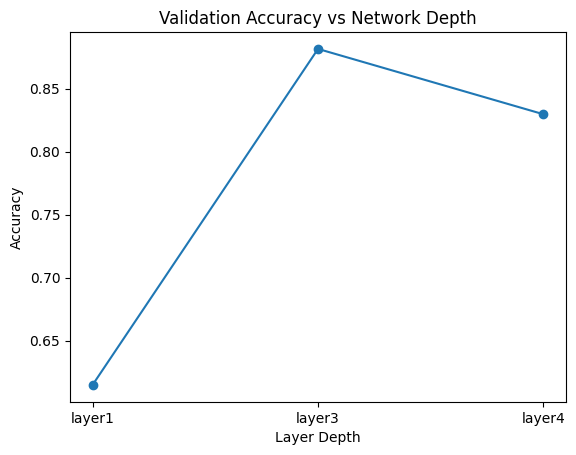

In [ ]:
layers = list(layer_results.keys())

accs = [layer_results[l]["accuracy"] for l in layers]

plt.plot(layers, accs, marker="o")
plt.title("Validation Accuracy vs Network Depth")
plt.xlabel("Layer Depth")
plt.ylabel("Accuracy")

plt.show()


In [ ]:
layer_results = {}

for layer_name in probe_layers:
    feats, labs = extract_features(layer_name)
    acc = train_linear_probe(feats, labs)
    mean_norm, std_norm = feature_norm_stats(feats)
    layer_results[layer_name] = {
        "accuracy": acc,
        "mean_norm": mean_norm,
        "std_norm": std_norm
    }

    print(layer_name, acc, mean_norm, std_norm)

layer1 0.737037037037037 18.695248 0.48813364
layer3 0.8888888888888888 44.549217 1.1763914
layer4 0.8481481481481481 6.7094088 0.8358435


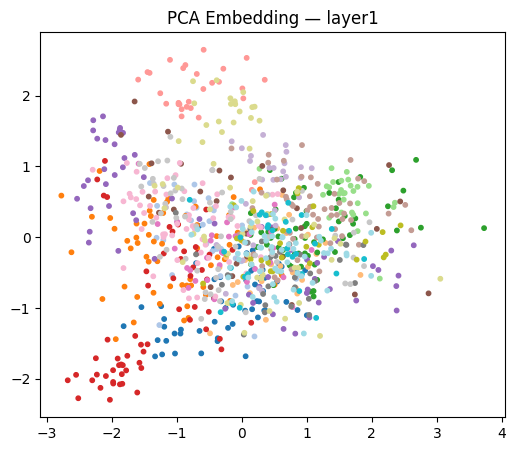

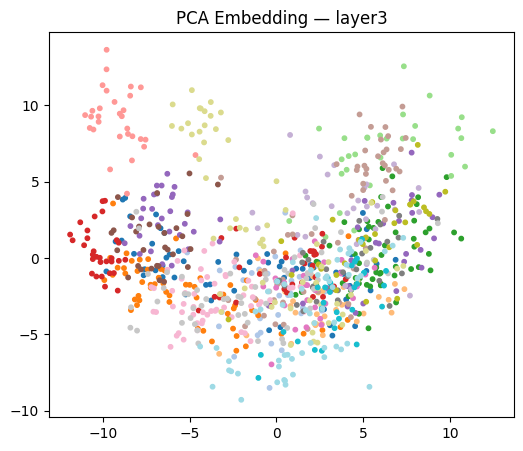

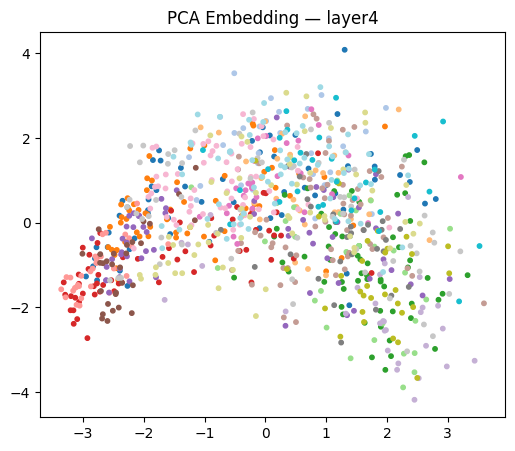

In [ ]:
from sklearn.decomposition import PCA
for layer_name in probe_layers:

    feats, labs = extract_features(layer_name)
    pca = PCA(n_components=2)
    reduced = pca.fit_transform(feats)

    plt.figure(figsize=(6,5))
    plt.scatter(
        reduced[:,0],
        reduced[:,1],
        c=labs,
        cmap="tab20",
        s=10
    )
    plt.title(f"PCA Embedding — {layer_name}")
    plt.show()
